In [1]:
import pandas as pd
import wandb
from wandb.apis.public.runs import Run
import seaborn as sns
import matplotlib.pyplot as plt
import re

In [2]:
api = wandb.Api()

In [3]:
runs = api.runs("graphcore/llama-mobile", filters={"config.name": "individual-layers-v1"})

In [4]:
def layer_no(layer_name):
    m = re.search("vision_model.transformer.layers.(\d+)", layer_name)
    if m:
        return int(m.group(1))
    m = re.search("vision_model.global_transformer.layers.(\d+)", layer_name)
    if m:
        return int(m.group(1)) + 32
    m = re.search("language_model.model.embed_tokens", layer_name)
    if m:
        return 40
    m = re.search("language_model.model.layers.(\d+)", layer_name)
    if m:
        return int(m.group(1)) + 41
    m = re.search("language_model.lm_head.weight", layer_name)
    if m:
        return 81
    return -1

In [5]:
def cleanup_run(run: Run) -> dict[str, any]:
    d = {}
    el_format = run.config["quantisation_formats"][1][1]["element_format"]
    d["format"] = f"E{el_format['exponent_bits']}M{el_format['mantissa_bits']}"
    d["layer"] = run.config["quantisation_formats"][1][0]
    d["layer_no"] = layer_no(d["layer"])
    d.update(run.summary)
    d.pop("_wandb")
    return d

In [6]:
df = pd.DataFrame([cleanup_run(run) for run in runs])
df.sort_values(by='layer_no', ascending=True, inplace=True)


In [7]:
df

,format,layer,layer_no,duration,edit_distance_L16,edit_distance_L16_stderr,entropy_rmse,entropy_rmse_stderr,exact_match_length,exact_match_length_stderr,n_bytes,n_params
1,E5M2,vision_model.transformer.layers.0,0,480.023200,1.808,0.176512,0.264546,0.008686,40.240002,1.095798,21322009670,10670220835
83,E2M1,vision_model.transformer.layers.0,0,497.504661,2.510,0.200090,0.370774,0.011558,35.209999,1.120355,21312179270,10670220835
84,E2M1,vision_model.transformer.layers.1,1,497.335341,3.188,0.221295,0.575923,0.017364,28.124001,1.064554,21029555270,10670220835
2,E5M2,vision_model.transformer.layers.1,1,482.481079,2.362,0.188438,0.370178,0.011656,35.734001,1.140526,21137689670,10670220835
3,E5M2,vision_model.transformer.layers.2,2,487.685375,2.342,0.195854,0.288372,0.009616,35.512001,1.121727,21137689670,10670220835
...,...,...,...,...,...,...,...,...,...,...,...,...
161,E2M1,language_model.model.layers.38,79,501.086745,1.786,0.172057,0.076154,0.001285,39.694000,1.115596,21026917446,10670220835
162,E2M1,language_model.model.layers.39,80,497.835809,3.124,0.210889,0.083370,0.000884,26.784000,1.046584,21026917446,10670220835
80,E5M2,language_model.model.layers.39,80,479.936401,1.568,0.158963,0.046130,0.000445,39.984001,1.087790,21135969350,10670220835
81,E5M2,language_model.lm_head.weight,81,478.961921,2.320,0.185537,0.073827,0.000699,32.388000,1.102398,20847938630,10670220835


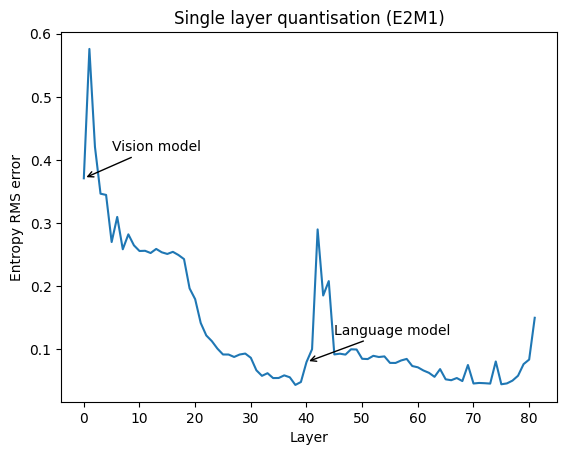

In [8]:
plt.figure()
df_fp4 = df[df["format"] == "E2M1"]
plt.plot(df_fp4["layer_no"], df_fp4["entropy_rmse"])
plt.xlabel("Layer")
plt.ylabel("Entropy RMS error")
plt.title("Single layer quantisation (E2M1)")

# Annotate start of language model
for l, text in [(0, "Vision model"), (40, "Language model")]:
    e = df_fp4[df_fp4["layer_no"] == l]["entropy_rmse"].item()
    plt.annotate(
        text,
        xy=(l, e),
        xytext=(20, 20),
        textcoords="offset points",
        arrowprops=dict(facecolor='black', arrowstyle='->')  # Arrow style
    )


plt.show()

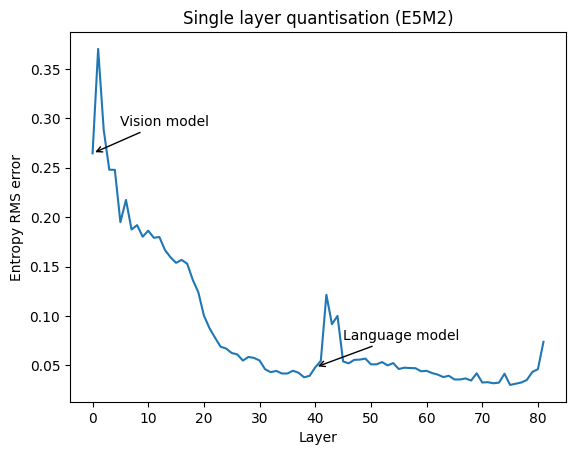

In [9]:
plt.figure()
df_fp8 = df[df["format"] == "E5M2"]
plt.plot(df_fp8["layer_no"], df_fp8["entropy_rmse"])
plt.xlabel("Layer")
plt.ylabel("Entropy RMS error")
plt.title("Single layer quantisation (E5M2)")

# Annotate start of language model
for l, text in [(0, "Vision model"), (40, "Language model")]:
    e = df_fp8[df_fp8["layer_no"] == l]["entropy_rmse"].item()
    plt.annotate(
        text,
        xy=(l, e),
        xytext=(20, 20),
        textcoords="offset points",
        arrowprops=dict(facecolor='black', arrowstyle='->')  # Arrow style
    )

plt.show()